In [21]:
import re
import numpy as np
import pandas as pd
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score,classification_report

In [2]:
fake_df=pd.read_csv('Fake.csv')
true_df=pd.read_csv('True.csv')
fake_df=fake_df.drop(['date','subject'],axis=1)
true_df=true_df.drop(['date','subject'],axis=1)
fake_df['label'],true_df['label']=0,1
fake_df.head()
true_df.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [3]:
def clean(text):

    text=text.lower()
    text=re.sub(r'http\S+|www\S+', '', text)
    text=re.sub(r'<.*?>', '', text)
    text=re.sub(r'[^a-z\s]', '', text)
    text=re.sub(r'\s+', ' ', text).strip()
    return text

In [4]:
fake_df['title']=fake_df['title'].apply(clean)
fake_df['text']=fake_df['text'].apply(clean)
true_df['title']=true_df['title'].apply(clean)
true_df['text']=true_df['text'].apply(clean)

In [5]:
df=pd.concat([fake_df,true_df],ignore_index=True)
df['content']=df['title']+" "+df['text']
df=df.drop(['title','text'],axis=1)
df.head()


,label,content
0,0,donald trump sends out embarrassing new years ...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obamas name c...
4,0,pope francis just called out donald trump duri...


In [6]:
x=df['content']
y=df['label']
x.head()
y.head()
y.unique()

array([0, 1])

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=20)


In [8]:
tfidf=TfidfVectorizer(max_features=5000)
x_train=tfidf.fit_transform(x_train)
x_test=tfidf.transform(x_test)


In [9]:
np.unique(x_train.data)

array([0.00130014, 0.00136971, 0.0015984 , ..., 0.84826272, 0.86526613,
       0.99285694], shape=(4177129,))

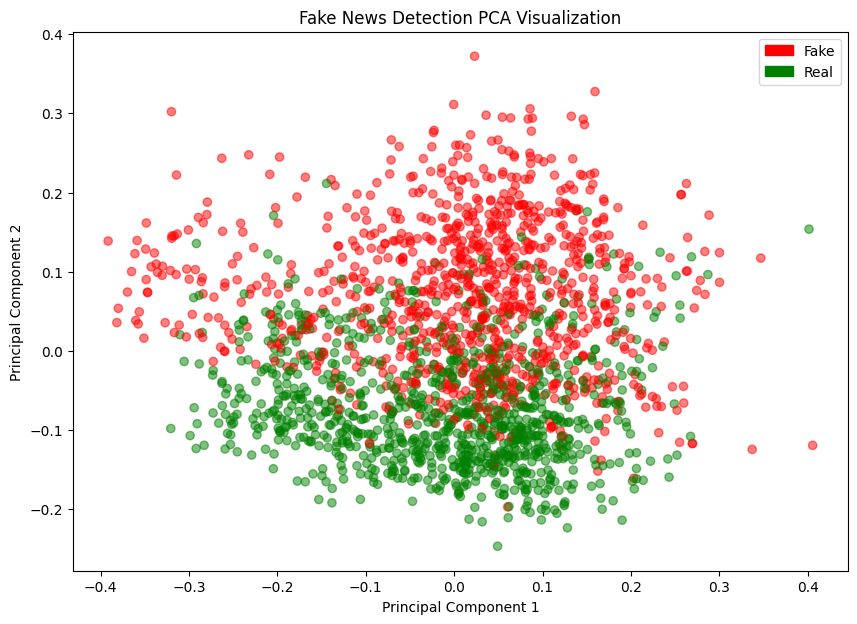

In [10]:
sample_size = 2000

X_sample = x_train[:sample_size].toarray()
y_sample = y_train.iloc[:sample_size]

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

colors = ['red' if label == 0 else 'green' for label in y_sample]

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=colors,
    alpha=0.5
)


red_patch = mpatches.Patch(color='red', label='Fake')
green_patch = mpatches.Patch(color='green', label='Real')

plt.legend(handles=[red_patch, green_patch])

plt.title("Fake News Detection PCA Visualization")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

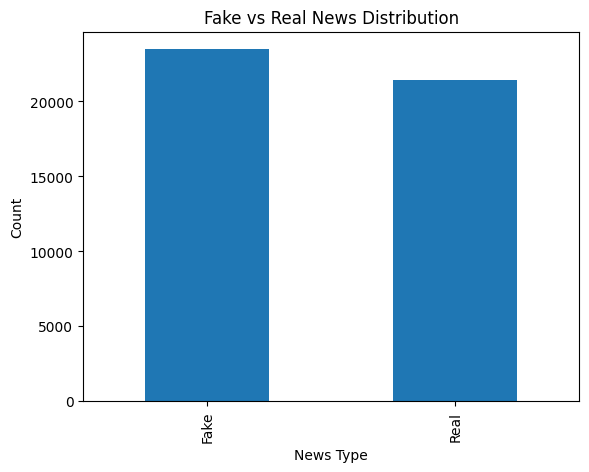

In [11]:
df['label'].value_counts().plot(kind='bar')

plt.xticks([0,1], ['Fake', 'Real'])

plt.xlabel("News Type")
plt.ylabel("Count")
plt.title("Fake vs Real News Distribution")

plt.show()

In [12]:
model1=LogisticRegression()
model2=LinearSVC()
model3=MultinomialNB()
param_svm_lr={'C':[0.01,0.1,1,10]}
param_nb={'alpha':[0.01,0.1,1,10]}
op1=GridSearchCV(model1,param_svm_lr,cv=5,scoring='f1')
op1.fit(x_train,y_train)
op2=GridSearchCV(model2,param_svm_lr,cv=5,scoring='f1')
op2.fit(x_train,y_train)
op3=GridSearchCV(model3,param_nb,cv=5,scoring='f1')
op3.fit(x_train,y_train)
print(op1.best_estimator_,op2.best_estimator_,op3.best_estimator_)


LogisticRegression(C=10) LinearSVC(C=1) MultinomialNB(alpha=0.01)


In [15]:
estimators=[('lr',LogisticRegression(C=10)),('svm',LinearSVC(C=1)),('nb',MultinomialNB(alpha=0.01))]
votingh_model=VotingClassifier(estimators=estimators,voting='hard')
votingh_model.fit(x_train,y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(C=10)),
                             ('svm', LinearSVC(C=1)),
                             ('nb', MultinomialNB(alpha=0.01))])

In [20]:
yh_pred=votingh_model.predict(x_test)
print(classification_report(y_test,yh_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9382
           1       0.99      0.99      0.99      8578

    accuracy                           0.99     17960
   macro avg       0.99      0.99      0.99     17960
weighted avg       0.99      0.99      0.99     17960



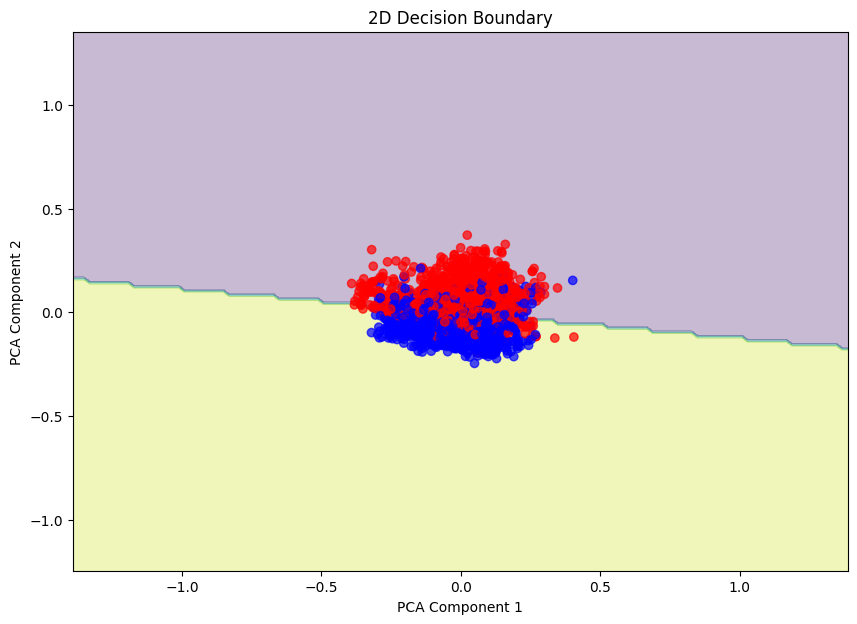

In [ ]:
sample_size = 2000
X_sample = x_train[:sample_size].toarray()
y_sample = y_train[:sample_size]
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_sample)
model_2d = SVC(kernel='linear')
model_2d.fit(X_2d, y_sample)
x_min, x_max = X_2d[:,0].min()-1, X_2d[:,0].max()+1
y_min, y_max = X_2d[:,1].min()-1, X_2d[:,1].max()+1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)
Z = model_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10,7))
plt.contourf(xx, yy, Z, alpha=0.3)
colors = ['red' if label == 0 else 'blue' for label in y_sample]
plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=colors,
    alpha=0.7
)
plt.title("2D Decision Boundary")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()